In [5]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import warnings
import joblib
import sys
warnings.filterwarnings('ignore')

# Add parent directory to path to import model_utils
sys.path.append('..')

from model_utils import (
    load_data, prepare_data, train_all_models, 
    plot_multi_week_comparison, plot_confusion_matrices,
    print_class_distribution, save_models
)

In [6]:
# Load data (ABSOLUTE sampling - first week of September 2024)
features_path = "../../data/ale_simplicistic_model/absolute/featured/features.parquet"
target_path = "../../data/ale_simplicistic_model/absolute/featured/target.parquet"

X, y_loaded, feature_cols = load_data(features_path, target_path)
print(f"Features shape: {X.shape}")
print(f"\nAbsolute Sampling: First week of September 2024 (Sept 1-7)")

✓ Features and targets aligned by did_id: 100000 samples
Features shape: (100000, 20)

Absolute Sampling: First week of September 2024 (Sept 1-7)


## Multi-Horizon Prediction Strategy: Weeks 2, 3 & 4 (Absolute Sampling)

We'll train **separate single-output models** for Week 2, 3 and 4 predictions from Week 1 features:
- 0 blocks → class 0 (Inactive)
- 1–3 blocks → class 1 (Low activity)
- 4+ blocks → class 2 (High activity)

**Absolute Sampling Time Windows:**
- **Week 1 (features):** Sept 1-7, 2024
- **Week 2 (target):** Sept 8-14, 2024
- **Week 3 (target):** Sept 15-21, 2024
- **Week 4 (target):** Sept 22-28, 2024

**Key approach:**
- Train 9 models total: 3 models per week × 3 weeks
- Each model type: Logistic Regression, Random Forest, Gradient Boosting
- Week 2 results imported from `4-model_second_week_absolute.ipynb`

**Goals:**
1. Predict user behavior for Weeks 2, 3, and 4 (multiple horizons)
2. Compare model performance across different prediction horizons
3. Visualize how predictability changes with time in a fixed calendar period

In [7]:
# Extract targets for all weeks
y_week2 = y_loaded['blocks_week2_class'].astype(int)
y_week3 = y_loaded['blocks_week3_class'].astype(int)
y_week4 = y_loaded['blocks_week4_class'].astype(int)

print('='*70)
print('CLASS DISTRIBUTIONS (Absolute Sampling - September 2024)')
print('='*70)

for week_num, y_target, dates in [
    ('Week 2', y_week2, 'Sept 8-14'),
    ('Week 3', y_week3, 'Sept 15-21'),
    ('Week 4', y_week4, 'Sept 22-28')
]:
    print_class_distribution(y_target, f"{week_num} ({dates})")

CLASS DISTRIBUTIONS (Absolute Sampling - September 2024)

Week 2 (Sept 8-14) class distribution:
  Class 0: 50,817 samples (50.8%)
  Class 1: 29,777 samples (29.8%)
  Class 2: 19,406 samples (19.4%)

Week 3 (Sept 15-21) class distribution:
  Class 0: 57,059 samples (57.1%)
  Class 1: 27,225 samples (27.2%)
  Class 2: 15,716 samples (15.7%)

Week 4 (Sept 22-28) class distribution:
  Class 0: 60,215 samples (60.2%)
  Class 1: 24,702 samples (24.7%)
  Class 2: 15,083 samples (15.1%)


In [8]:
# Prepare data for each week (separate stratified splits)
print('='*70)
print('PREPARING DATA FOR EACH WEEK')
print('='*70)

data_week2 = prepare_data(X, y_week2, test_size=0.5, random_state=42)
data_week3 = prepare_data(X, y_week3, test_size=0.5, random_state=42)
data_week4 = prepare_data(X, y_week4, test_size=0.5, random_state=42)

print('\n✓ All data prepared')

PREPARING DATA FOR EACH WEEK
Train/Test split: (50000, 20) / (50000, 20)
Train/Test split: (50000, 20) / (50000, 20)
Train/Test split: (50000, 20) / (50000, 20)

✓ All data prepared


## Train Models for Each Week

Import Week 2 results and train models for Weeks 3 & 4.

In [9]:
# Load pre-trained Week 2 results from 4-model_second_week_absolute.ipynb
try:
    results_week2 = joblib.load("../../data/ale_simplicistic_model/absolute/model_ready/results_week2.pkl")
    print("✓ Loaded pre-trained Week 2 models from 4-model_second_week_absolute.ipynb")
    print(f"  Models: {list(results_week2.keys())}")
    print(f"  Week 2 Best F1 (macro): {max(r['f1_macro'] for r in results_week2.values()):.4f}")
except FileNotFoundError:
    print("⚠️  Week 2 results not found. Training Week 2 models...")
    results_week2 = train_all_models(data_week2, week_label="Week 2 (Absolute)")

✓ Loaded pre-trained Week 2 models from 4-model_second_week_absolute.ipynb
  Models: ['LogisticRegression', 'RandomForest', 'GradientBoosting']
  Week 2 Best F1 (macro): 0.5098


### Train Week 3 Models

In [10]:
# Train models for Week 3
results_week3 = train_all_models(data_week3, week_label="Week 3 (Absolute)")

TRAINING ALL MODELS - Week 3 (Absolute)

LogisticRegression (Week 3 (Absolute)):
  Accuracy: 0.5463
  Macro F1: 0.4895
  Weighted F1: 0.5507

RandomForest (Week 3 (Absolute)):
  Accuracy: 0.5749
  Macro F1: 0.4896
  Weighted F1: 0.5632

GradientBoosting (Week 3 (Absolute)):
  Accuracy: 0.6167
  Macro F1: 0.4624
  Weighted F1: 0.5541

✓ All models trained


### Train Week 4 Models

In [11]:
# Train models for Week 4
results_week4 = train_all_models(data_week4, week_label="Week 4 (Absolute)")

TRAINING ALL MODELS - Week 4 (Absolute)

LogisticRegression (Week 4 (Absolute)):
  Accuracy: 0.5556
  Macro F1: 0.4821
  Weighted F1: 0.5628

RandomForest (Week 4 (Absolute)):
  Accuracy: 0.5982
  Macro F1: 0.4852
  Weighted F1: 0.5830

GradientBoosting (Week 4 (Absolute)):
  Accuracy: 0.6408
  Macro F1: 0.4462
  Weighted F1: 0.5662

✓ All models trained


## Multi-Week Performance Comparison

Compare how model performance changes across prediction horizons in the absolute sampling approach.

MODEL PERFORMANCE ACROSS WEEKS
             Model  Accuracy  Macro F1  Weighted F1   Week
LogisticRegression  0.538475  0.499456     0.533442 Week 2
      RandomForest  0.557425  0.509800     0.547613 Week 2
  GradientBoosting  0.588925  0.497279     0.544691 Week 2
LogisticRegression  0.546340  0.489493     0.550723 Week 3
      RandomForest  0.574900  0.489590     0.563224 Week 3
  GradientBoosting  0.616720  0.462378     0.554138 Week 3
LogisticRegression  0.555640  0.482087     0.562779 Week 4
      RandomForest  0.598180  0.485170     0.582973 Week 4
  GradientBoosting  0.640780  0.446154     0.566227 Week 4


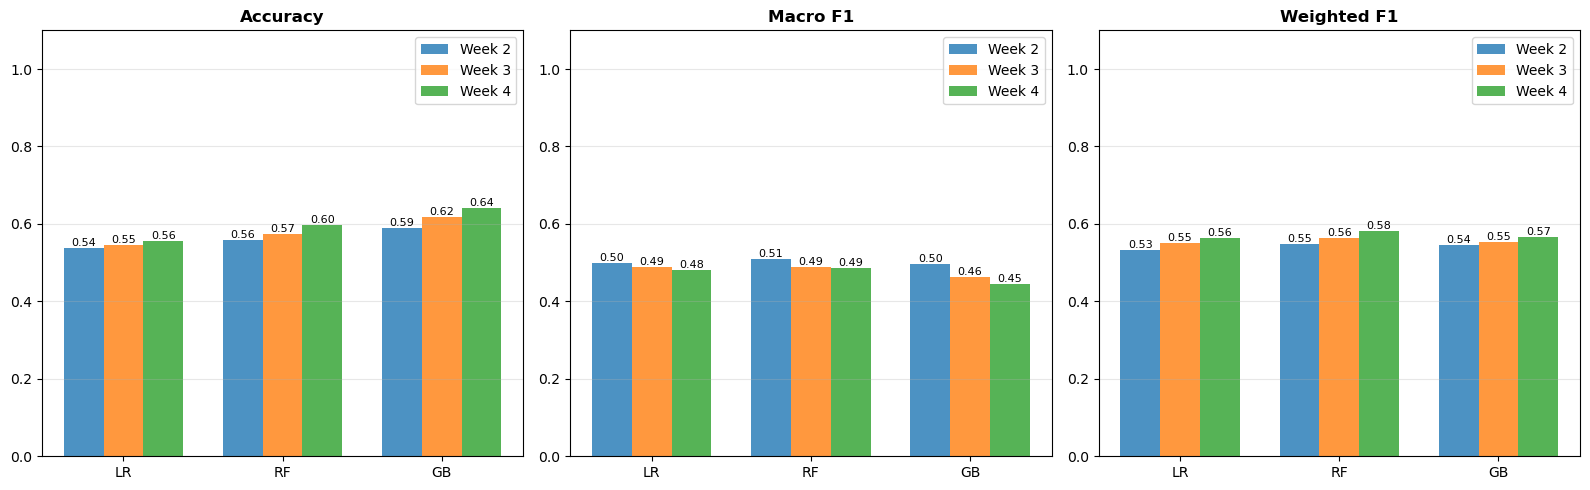

In [12]:
# Combine all results for comparison
all_results = {
    'Week 2': results_week2,
    'Week 3': results_week3,
    'Week 4': results_week4
}

# Plot multi-week comparison
comparison_df = plot_multi_week_comparison(
    all_results, 
    weeks=['Week 2', 'Week 3', 'Week 4']
)

In [13]:
# Per-class F1 scores analysis
print('\n' + '='*80)
print('PER-CLASS F1 SCORES ACROSS WEEKS (Absolute Sampling)')
print('='*80)

models = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
model_display = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

week_dates = {
    'Week 2': 'Sept 8-14',
    'Week 3': 'Sept 15-21',
    'Week 4': 'Sept 22-28'
}

for week in ['Week 2', 'Week 3', 'Week 4']:
    print(f'\n{week} ({week_dates[week]}):')
    for model_key, model_name in zip(models, model_display):
        print(f"  {model_name}:")
        f1_scores = all_results[week][model_key]['f1_per_class']
        print(f"    Class 0 (Inactive):  F1 = {f1_scores[0]:.4f}")
        print(f"    Class 1 (Low 1-3):   F1 = {f1_scores[1]:.4f}")
        print(f"    Class 2 (High 4+):   F1 = {f1_scores[2]:.4f}")


PER-CLASS F1 SCORES ACROSS WEEKS (Absolute Sampling)

Week 2 (Sept 8-14):
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6653
    Class 1 (Low 1-3):   F1 = 0.3248
    Class 2 (High 4+):   F1 = 0.5082
  Random Forest:
    Class 0 (Inactive):  F1 = 0.6866
    Class 1 (Low 1-3):   F1 = 0.3390
    Class 2 (High 4+):   F1 = 0.5038
  Gradient Boosting:
    Class 0 (Inactive):  F1 = 0.7271
    Class 1 (Low 1-3):   F1 = 0.2584
    Class 2 (High 4+):   F1 = 0.5063

Week 3 (Sept 15-21):
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6827
    Class 1 (Low 1-3):   F1 = 0.3274
    Class 2 (High 4+):   F1 = 0.4583
  Random Forest:
    Class 0 (Inactive):  F1 = 0.7182
    Class 1 (Low 1-3):   F1 = 0.3082
    Class 2 (High 4+):   F1 = 0.4424
  Gradient Boosting:
    Class 0 (Inactive):  F1 = 0.7613
    Class 1 (Low 1-3):   F1 = 0.1861
    Class 2 (High 4+):   F1 = 0.4398

Week 4 (Sept 22-28):
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6992
    Class 1 (Low 1-3):   F1 = 0.3

## Save Models

Save trained models for Weeks 3 and 4 (Week 2 already saved in `4-model_second_week_absolute.ipynb`).

In [14]:
# Save Week 3 models
metadata_week3 = save_models(
    results_week3,
    scaler=data_week3['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 3 (Absolute)",
    model_dir="../../data/ale_simplicistic_model/absolute/model_ready"
)

# Save Week 4 models
metadata_week4 = save_models(
    results_week4,
    scaler=data_week4['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 4 (Absolute)",
    model_dir="../../data/ale_simplicistic_model/absolute/model_ready"
)

print("\n✓ All models saved successfully!")


SAVING MODELS - Week 3 (Absolute)
✓ LogisticRegression saved: ../../data/ale_simplicistic_model/absolute/model_ready/logisticregression_week3(absolute)_20260201_212916.pkl
✓ RandomForest saved: ../../data/ale_simplicistic_model/absolute/model_ready/randomforest_week3(absolute)_20260201_212916.pkl
✓ GradientBoosting saved: ../../data/ale_simplicistic_model/absolute/model_ready/gradientboosting_week3(absolute)_20260201_212916.pkl
✓ Scaler saved: ../../data/ale_simplicistic_model/absolute/model_ready/scaler_week3(absolute)_20260201_212916.pkl
✓ Metadata saved: ../../data/ale_simplicistic_model/absolute/model_ready/metadata_week3(absolute)_20260201_212916.pkl

SAVING MODELS - Week 4 (Absolute)
✓ LogisticRegression saved: ../../data/ale_simplicistic_model/absolute/model_ready/logisticregression_week4(absolute)_20260201_212917.pkl
✓ RandomForest saved: ../../data/ale_simplicistic_model/absolute/model_ready/randomforest_week4(absolute)_20260201_212917.pkl
✓ GradientBoosting saved: ../../data

## Summary

Compare relative vs absolute sampling approaches.

In [15]:
# Summary of absolute sampling approach
print('\n' + '='*80)
print('ABSOLUTE SAMPLING SUMMARY')
print('='*80)
print(f"\nTime Period: September 2024")
print(f"  Week 1 (features): Sept 1-7, 2024")
print(f"  Week 2 (target):   Sept 8-14, 2024")
print(f"  Week 3 (target):   Sept 15-21, 2024")
print(f"  Week 4 (target):   Sept 22-28, 2024")

print(f"\nTotal users: {len(X)}")
print(f"Total features: {len(feature_cols)}")

print(f"\nBest Models (by Macro F1):")
for week in ['Week 2', 'Week 3', 'Week 4']:
    best_model = max(all_results[week].items(), key=lambda x: x[1]['f1_macro'])
    print(f"  {week}: {best_model[0]} (F1 Macro = {best_model[1]['f1_macro']:.4f})")

print(f"\nKey Insight:")
print(f"  Absolute sampling analyzes user behavior in a fixed calendar period,")
print(f"  allowing us to understand how block activity evolves in real time.")
print(f"  This complements the relative sampling approach which looks at")
print(f"  behavior relative to each user's join date.")


ABSOLUTE SAMPLING SUMMARY

Time Period: September 2024
  Week 1 (features): Sept 1-7, 2024
  Week 2 (target):   Sept 8-14, 2024
  Week 3 (target):   Sept 15-21, 2024
  Week 4 (target):   Sept 22-28, 2024

Total users: 100000
Total features: 20

Best Models (by Macro F1):
  Week 2: RandomForest (F1 Macro = 0.5098)
  Week 3: RandomForest (F1 Macro = 0.4896)
  Week 4: RandomForest (F1 Macro = 0.4852)

Key Insight:
  Absolute sampling analyzes user behavior in a fixed calendar period,
  allowing us to understand how block activity evolves in real time.
  This complements the relative sampling approach which looks at
  behavior relative to each user's join date.


✓ Comparison plot saved to: ../../data/ale_simplicistic_model/absolute/absolute_vs_relative_comparison.png


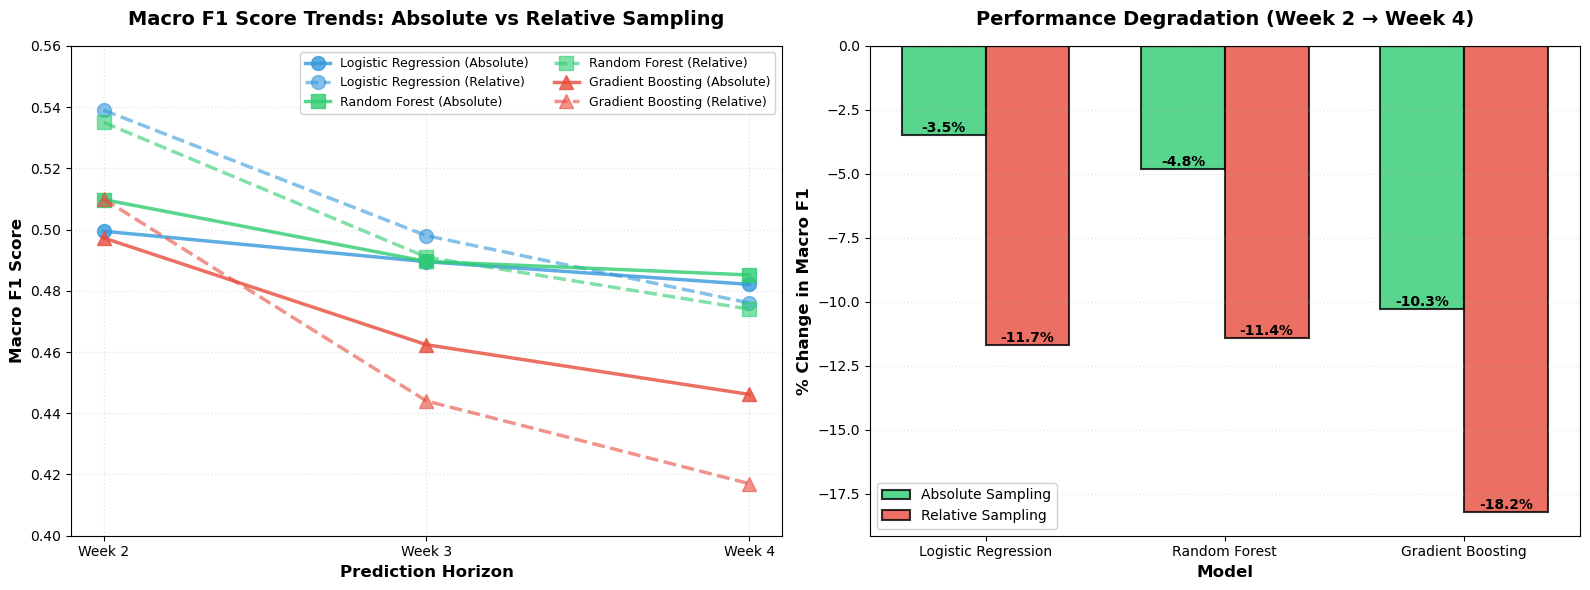


ABSOLUTE vs RELATIVE SAMPLING COMPARISON

Macro F1 Score Stability (Week 2 → Week 4):
--------------------------------------------------------------------------------
Model                     Absolute Change      Relative Change     
--------------------------------------------------------------------------------
Logistic Regression        -3.48%               -11.69%
Random Forest              -4.83%               -11.40%
Gradient Boosting         -10.28%               -18.24%
--------------------------------------------------------------------------------
Average                    -6.20%               -13.78%

💡 Key Finding:
   Absolute sampling shows 6.2% average degradation
   Relative sampling shows 13.8% average degradation
   → Absolute sampling is 7.6% more stable!

   This suggests that user behavior in fixed calendar periods
   is more predictable than behavior relative to join dates.


In [16]:
# Comparison: Absolute vs Relative Sampling - Macro F1 Scores
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Absolute sampling data (Macro F1 scores)
absolute_data = {
    'Week 2': {'LogisticRegression': 0.499456, 'RandomForest': 0.509800, 'GradientBoosting': 0.497279},
    'Week 3': {'LogisticRegression': 0.489493, 'RandomForest': 0.489590, 'GradientBoosting': 0.462378},
    'Week 4': {'LogisticRegression': 0.482087, 'RandomForest': 0.485170, 'GradientBoosting': 0.446154}
}

# Relative sampling data (Macro F1 scores)
relative_data = {
    'Week 2': {'LogisticRegression': 0.539, 'RandomForest': 0.535, 'GradientBoosting': 0.510},
    'Week 3': {'LogisticRegression': 0.498, 'RandomForest': 0.491, 'GradientBoosting': 0.444},
    'Week 4': {'LogisticRegression': 0.476, 'RandomForest': 0.474, 'GradientBoosting': 0.417}
}

# Prepare data for plotting
weeks = ['Week 2', 'Week 3', 'Week 4']
models = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
model_labels = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors for each model
colors = ['#3498db', '#2ecc71', '#e74c3c']
markers = ['o', 's', '^']

# Plot 1: Line chart comparing both approaches
ax1 = axes[0]
for idx, (model, label) in enumerate(zip(models, model_labels)):
    abs_scores = [absolute_data[week][model] for week in weeks]
    rel_scores = [relative_data[week][model] for week in weeks]
    
    # Absolute sampling (solid line)
    ax1.plot(weeks, abs_scores, marker=markers[idx], linewidth=2.5, markersize=10, 
             label=f'{label} (Absolute)', color=colors[idx], linestyle='-', alpha=0.8)
    
    # Relative sampling (dashed line)
    ax1.plot(weeks, rel_scores, marker=markers[idx], linewidth=2.5, markersize=10,
             label=f'{label} (Relative)', color=colors[idx], linestyle='--', alpha=0.6)

ax1.set_title('Macro F1 Score Trends: Absolute vs Relative Sampling', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Prediction Horizon', fontsize=12, fontweight='bold')
ax1.set_ylabel('Macro F1 Score', fontsize=12, fontweight='bold')
ax1.set_ylim([0.40, 0.56])
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=1)
ax1.legend(loc='best', fontsize=9, framealpha=0.9, ncol=2)

# Plot 2: Performance degradation (% change from Week 2 to Week 4)
ax2 = axes[1]

degradation_abs = []
degradation_rel = []

for model in models:
    # Calculate percentage change from Week 2 to Week 4
    abs_change = ((absolute_data['Week 4'][model] - absolute_data['Week 2'][model]) / 
                  absolute_data['Week 2'][model] * 100)
    rel_change = ((relative_data['Week 4'][model] - relative_data['Week 2'][model]) / 
                  relative_data['Week 2'][model] * 100)
    
    degradation_abs.append(abs_change)
    degradation_rel.append(rel_change)

x = np.arange(len(model_labels))
width = 0.35

bars1 = ax2.bar(x - width/2, degradation_abs, width, label='Absolute Sampling', 
                color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, degradation_rel, width, label='Relative Sampling', 
                color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height < 0 else 'top',
                fontsize=10, fontweight='bold')

ax2.set_title('Performance Degradation (Week 2 → Week 4)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Change in Macro F1', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_labels)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)

plt.tight_layout()

# Save the figure
output_path = '../../data/ale_simplicistic_model/absolute/absolute_vs_relative_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Comparison plot saved to: {output_path}")

plt.show()

# Print numerical summary
print('\n' + '='*80)
print('ABSOLUTE vs RELATIVE SAMPLING COMPARISON')
print('='*80)

print('\nMacro F1 Score Stability (Week 2 → Week 4):')
print('-' * 80)
print(f"{'Model':<25} {'Absolute Change':<20} {'Relative Change':<20}")
print('-' * 80)

for idx, (model, label) in enumerate(zip(models, model_labels)):
    print(f"{label:<25} {degradation_abs[idx]:>6.2f}% {' '*13} {degradation_rel[idx]:>6.2f}%")

avg_abs_deg = np.mean(degradation_abs)
avg_rel_deg = np.mean(degradation_rel)

print('-' * 80)
print(f"{'Average':<25} {avg_abs_deg:>6.2f}% {' '*13} {avg_rel_deg:>6.2f}%")
print('='*80)

print(f"\n💡 Key Finding:")
print(f"   Absolute sampling shows {abs(avg_abs_deg):.1f}% average degradation")
print(f"   Relative sampling shows {abs(avg_rel_deg):.1f}% average degradation")
print(f"   → Absolute sampling is {abs(avg_rel_deg - avg_abs_deg):.1f}% more stable!")
print(f"\n   This suggests that user behavior in fixed calendar periods")
print(f"   is more predictable than behavior relative to join dates.")